# 09 - Model Interpretation and Finalization

### Objective

Analyze feature importance, finalize the models for each stock, and save them for use in the StockVision prediction pipeline.

In [41]:
import json 
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib
from pathlib import Path

In [2]:
stocks = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS"
]

In [3]:
ml_data = {}

for stock in stocks:
    df = pd.read_csv(f"../data/ml_ready/{stock}_ml.csv", parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    ml_data[stock] = df

In [4]:
features = [
    "Daily_Return",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "SMA_5",
    "SMA_20",
    "SMA_50",
    "EMA_20",
    "Volatility_20",
    "Volume_Change",
    "High_Low_Range",
    "Open_Close_Change",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

target = "Target"

In [5]:
X = {}
y = {}

for stock in stocks:
    X[stock] = ml_data[stock][features]
    y[stock] = ml_data[stock][target]

## Chronological Train-Test Split

Use the first **80%** of observations to train the Random Forest models used for feature importance analysis.

In [6]:
X_train = {}
X_test  = {}

y_train = {}
y_test  = {}

for stock in stocks:
    
    split_idx = int(len(X[stock]) * 0.8)
    
    X_train[stock] = X[stock][:split_idx]
    X_test[stock] = X[stock][split_idx:]
    
    y_train[stock] = y[stock][:split_idx]
    y_test[stock] = y[stock][split_idx:]

## Random Forest Feature Importance

Feature importance measures the relative contribution of each input feature to the Random Forest model's predictions.

In [7]:
rf_models = {}

for stock in stocks:
    
    model = RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs= -1
    )
    
    model.fit(X_train[stock], y_train[stock])
    
    rf_models[stock] = model
    

## Feature Importance Analysis

Extract and rank the feature importance scores for each stock to identify the features that contribute most to the Random Forest predictions.

In [11]:
feature_importance = {}

for stock in stocks:
    
    importance_df = pd.DataFrame({
        "Feature" : features, 
        "Importance" : rf_models[stock].feature_importances_
    })
    
    importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    feature_importance[stock] = importance_df

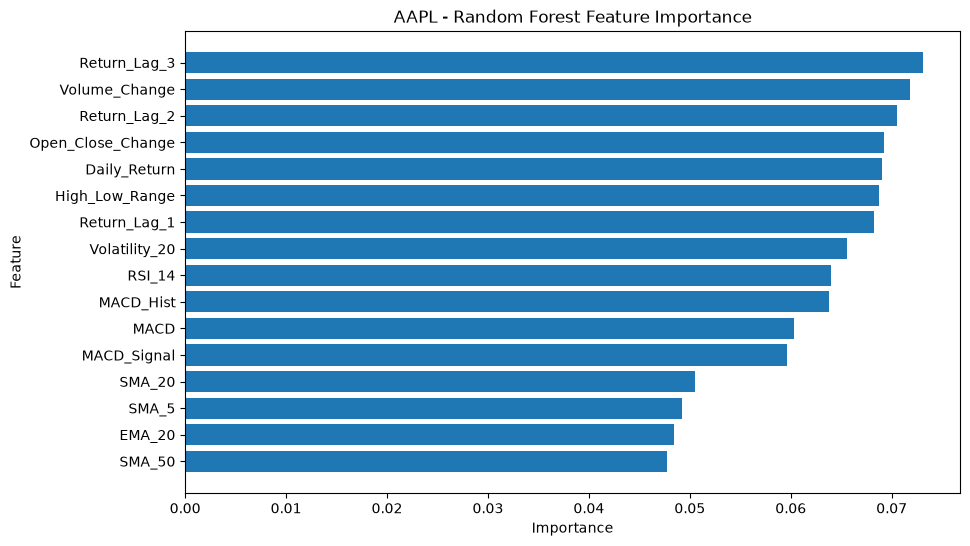

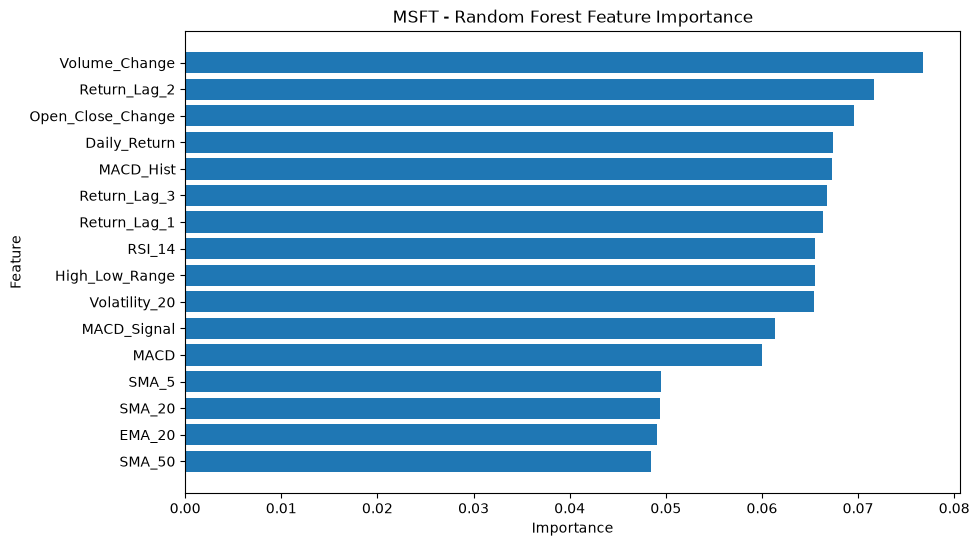

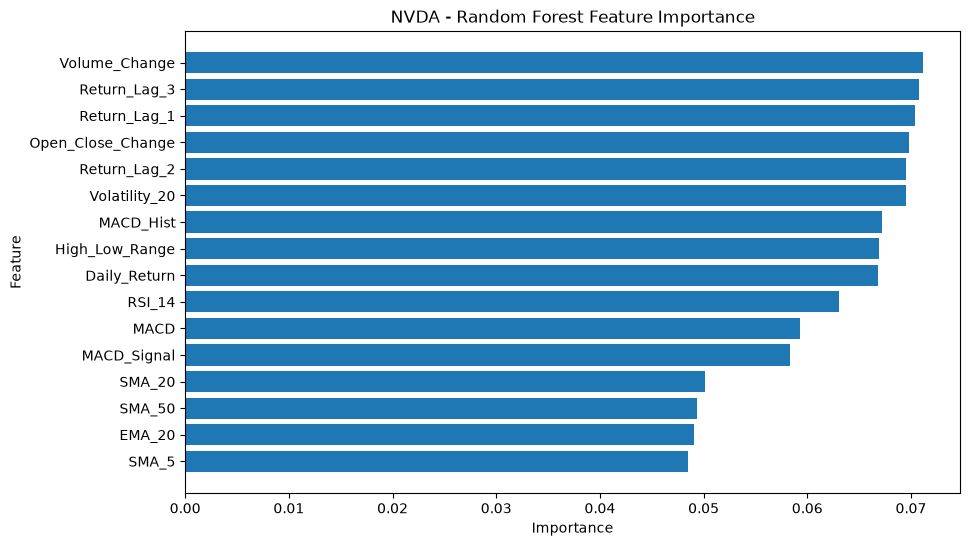

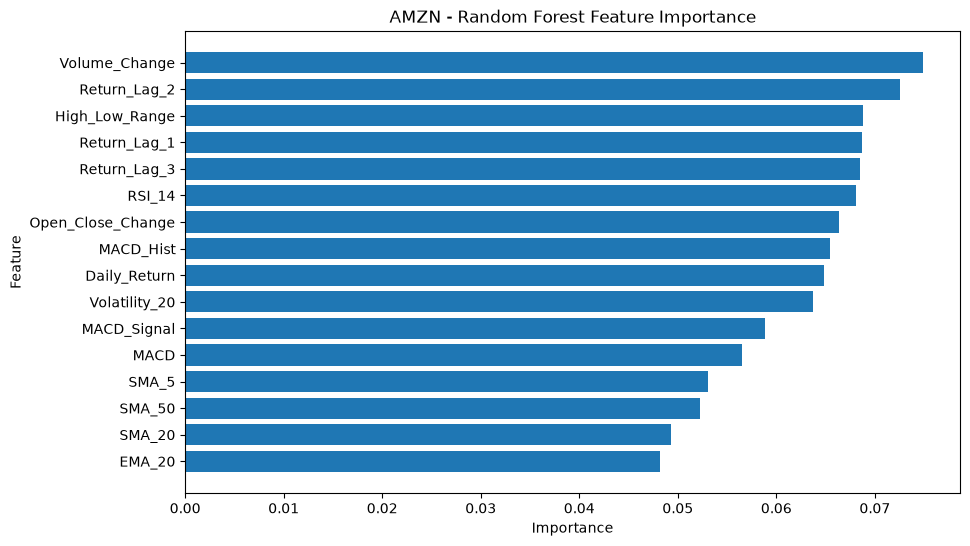

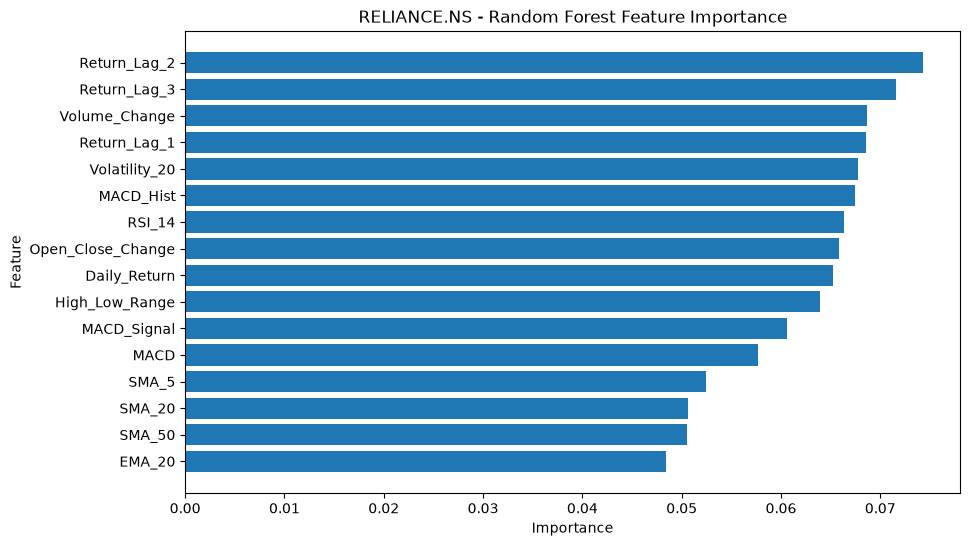

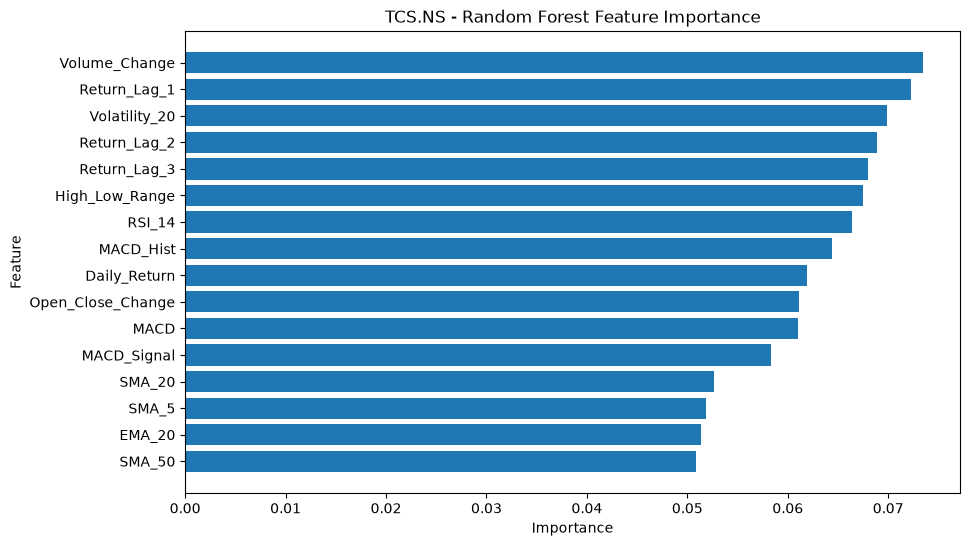

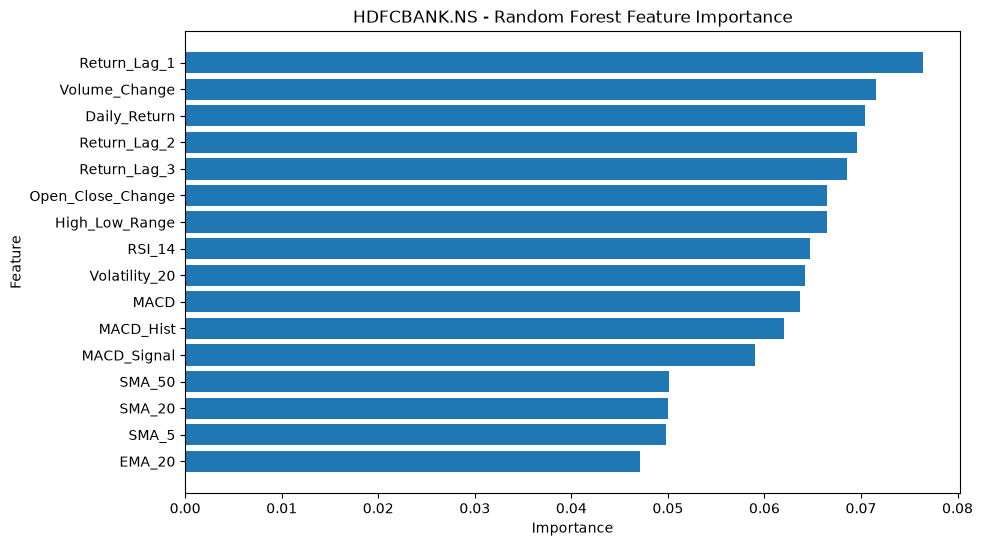

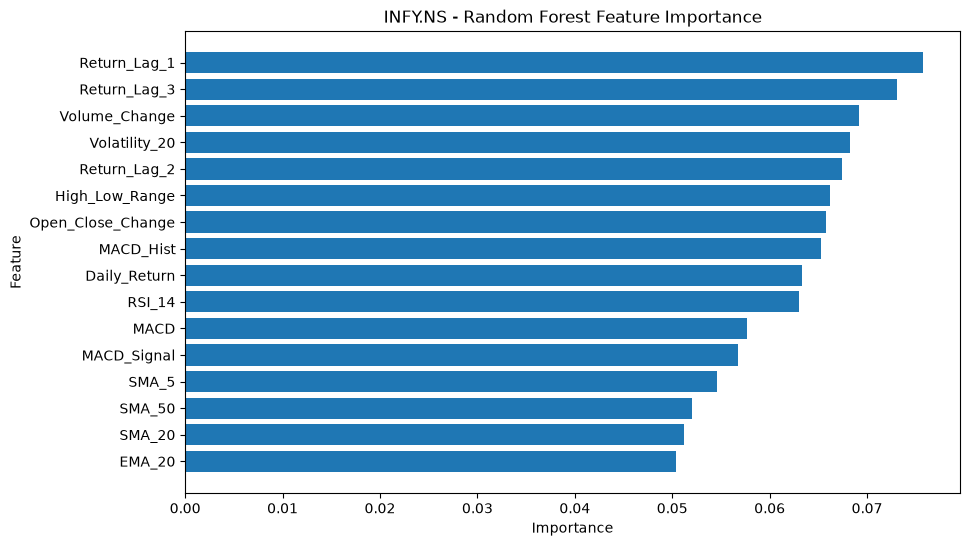

In [14]:
for stock in stocks:
    
    importance_df = feature_importance[stock]

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"{stock} - Random Forest Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

## Overall Feature Importance

Calculate the average feature importance across all stocks to identify the features that consistently influence Random Forest predictions.

In [19]:
overall_importance = pd.DataFrame({
    stock: feature_importance[stock]
        .set_index("Feature")["Importance"]
    for stock in stocks
})

overall_importance["Average_Importance"] = (
    overall_importance.mean(axis=1)
)

overall_importance = overall_importance.sort_values(
    "Average_Importance",
    ascending=False
)

overall_importance

,AAPL,MSFT,NVDA,AMZN,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,Average_Importance
Feature,,,,,,,,,
Volume_Change,0.071863,0.076780,0.071184,0.074911,0.068675,0.073487,0.071511,0.069181,0.072199
Return_Lag_1,0.068293,0.066373,0.070359,0.068737,0.068560,0.072293,0.076450,0.075767,0.070854
Return_Lag_2,0.070524,0.071673,0.069561,0.072562,0.074324,0.068867,0.069613,0.067432,0.070570
Return_Lag_3,0.073127,0.066718,0.070816,0.068531,0.071530,0.067993,0.068522,0.073109,0.070043
Volatility_20,0.065586,0.065380,0.069542,0.063736,0.067777,0.069897,0.064237,0.068295,0.066806
Open_Close_Change,0.069199,0.069574,0.069849,0.066316,0.065836,0.061155,0.066450,0.065755,0.066767
High_Low_Range,0.068746,0.065480,0.066922,0.068800,0.063953,0.067455,0.066442,0.066241,0.066755
Daily_Return,0.069070,0.067439,0.066798,0.064822,0.065190,0.061949,0.070364,0.063310,0.066118
MACD_Hist,0.063748,0.067249,0.067242,0.065415,0.067441,0.064446,0.062059,0.065225,0.065353


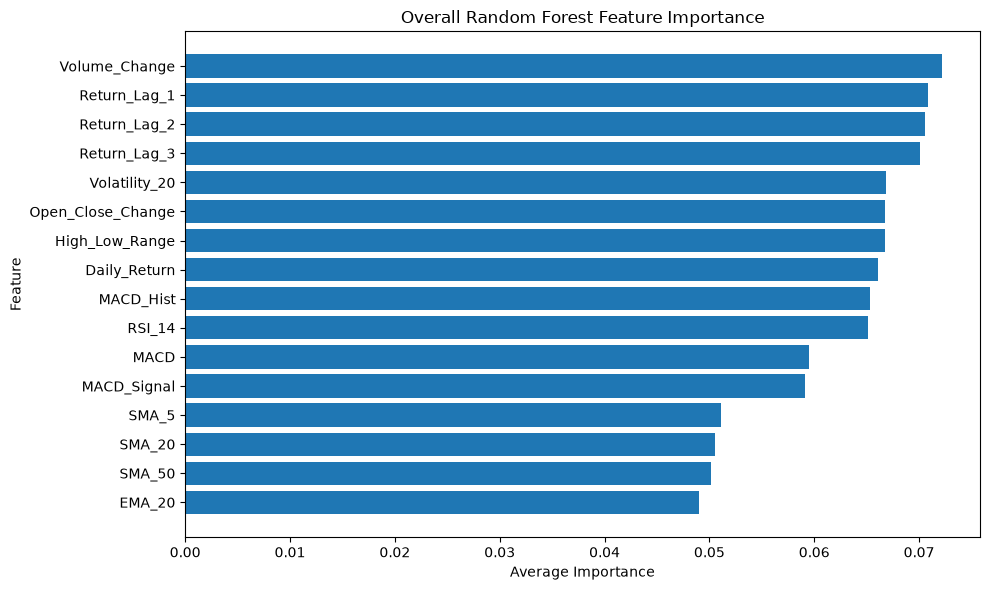

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(
    overall_importance.index,
    overall_importance["Average_Importance"]
)

plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.title("Overall Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Final Model Selection

Select the best-performing model for each stock based on the evaluation results obtained during model training and hyperparameter tuning.

In [26]:
logistic_results = pd.read_csv("../results/logistic_results.csv")
default_rf_results = pd.read_csv("../results/default_rf_results.csv")
tuned_rf_results = pd.read_csv("../results/tuned_rf_results.csv")

In [27]:
print("Logistic Regression")
display(logistic_results)

print("Default Random Forest")
display(default_rf_results)
print("Tuned Random Forest")
display(tuned_rf_results)

Logistic Regression


,Stock,Accuracy,Precision,Recall,F1-Score
0,AAPL,0.495396,0.533333,0.619529,0.573209
1,MSFT,0.497238,0.540717,0.557047,0.548760
2,NVDA,0.475138,0.758621,0.073333,0.133739
3,AMZN,0.502762,0.545918,0.371528,0.442149
4,RELIANCE.NS,0.491557,0.513514,0.544803,0.528696
5,TCS.NS,0.459662,0.450000,0.725806,0.555556
6,HDFCBANK.NS,0.480300,0.505952,0.604982,0.551053
7,INFY.NS,0.510319,0.504484,0.849057,0.632911


Default Random Forest


,Stock,Accuracy,Precision,Recall,F1-Score
0,AAPL,0.484346,0.548571,0.323232,0.406780
1,MSFT,0.462247,0.525862,0.204698,0.294686
2,NVDA,0.510129,0.641667,0.256667,0.366667
3,AMZN,0.486188,0.528662,0.288194,0.373034
4,RELIANCE.NS,0.521576,0.585714,0.293907,0.391408
5,TCS.NS,0.542214,0.514085,0.294355,0.374359
6,HDFCBANK.NS,0.469043,0.491071,0.195730,0.279898
7,INFY.NS,0.495310,0.489130,0.339623,0.400891


Tuned Random Forest


,Stock,Accuracy,Precision,Recall,F1_Score
0,AAPL,0.462247,0.511628,0.370370,0.429688
1,MSFT,0.464088,0.517588,0.345638,0.414487
2,NVDA,0.502762,0.734375,0.156667,0.258242
3,AMZN,0.484346,0.543478,0.173611,0.263158
4,RELIANCE.NS,0.489681,0.652174,0.053763,0.099338
5,TCS.NS,0.538462,0.506494,0.314516,0.388060
6,HDFCBANK.NS,0.485929,0.529915,0.220641,0.311558
7,INFY.NS,0.487805,0.485185,0.494340,0.489720


In [28]:
print(
    "Logistic:",
    logistic_results.columns.tolist()
)

print(
    "Default RF:",
    default_rf_results.columns.tolist()
)

print(
    "Tuned RF:",
    tuned_rf_results.columns.tolist()
)

Logistic: ['Stock', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
Default RF: ['Stock', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
Tuned RF: ['Stock', 'Accuracy', 'Precision', 'Recall', 'F1_Score']


## Model Comparison

Compare the test accuracy of Logistic Regression, Default Random Forest, and Tuned Random Forest for each stock.

In [30]:
comparison_df = pd.DataFrame({
    "Stock" : logistic_results['Stock'],
    "Logistic Regression" : logistic_results['Accuracy'],
    "Default Random Forest" : default_rf_results['Accuracy'],
    "Tuned Random Forest" : tuned_rf_results['Accuracy']
})

comparison_df

,Stock,Logistic Regression,Default Random Forest,Tuned Random Forest
0,AAPL,0.495396,0.484346,0.462247
1,MSFT,0.497238,0.462247,0.464088
2,NVDA,0.475138,0.510129,0.502762
3,AMZN,0.502762,0.486188,0.484346
4,RELIANCE.NS,0.491557,0.521576,0.489681
5,TCS.NS,0.459662,0.542214,0.538462
6,HDFCBANK.NS,0.480300,0.469043,0.485929
7,INFY.NS,0.510319,0.495310,0.487805


In [31]:
model_columns = [
    "Logistic Regression", 
    "Default Random Forest", 
    "Tuned Random Forest"
]

comparison_df["Best Model"] = comparison_df[model_columns].idxmax(axis=1)

comparison_df["Best Accuracy"] = comparison_df[model_columns].max(axis=1)

comparison_df

,Stock,Logistic Regression,Default Random Forest,Tuned Random Forest,Best Model,Best Accuracy
0,AAPL,0.495396,0.484346,0.462247,Logistic Regression,0.495396
1,MSFT,0.497238,0.462247,0.464088,Logistic Regression,0.497238
2,NVDA,0.475138,0.510129,0.502762,Default Random Forest,0.510129
3,AMZN,0.502762,0.486188,0.484346,Logistic Regression,0.502762
4,RELIANCE.NS,0.491557,0.521576,0.489681,Default Random Forest,0.521576
5,TCS.NS,0.459662,0.542214,0.538462,Default Random Forest,0.542214
6,HDFCBANK.NS,0.480300,0.469043,0.485929,Tuned Random Forest,0.485929
7,INFY.NS,0.510319,0.495310,0.487805,Logistic Regression,0.510319


## Final Model Selection

Select the best-performing model for each stock based on the comparison results.

In [39]:
final_model_choice = dict(
    zip(
        comparison_df["Stock"],
        comparison_df["Best Model"]
    )
)

final_model_choice

{'AAPL': 'Logistic Regression',
 'MSFT': 'Logistic Regression',
 'NVDA': 'Default Random Forest',
 'AMZN': 'Logistic Regression',
 'RELIANCE.NS': 'Default Random Forest',
 'TCS.NS': 'Default Random Forest',
 'HDFCBANK.NS': 'Tuned Random Forest',
 'INFY.NS': 'Logistic Regression'}

In [35]:
with open("../models/best_rf_params.json", "r") as f:
    best_params = json.load(f)

In [36]:
best_params["HDFCBANK.NS"]

{'n_estimators': 201,
 'max_depth': 13,
 'min_samples_split': 9,
 'min_samples_leaf': 8}

## Final Model Training

Retrain the selected model for each stock using all available labeled data, preparing the models for the prediction pipeline.

In [40]:
final_models = {}

for stock in stocks:
    
    model_name = final_model_choice[stock]
    
    # logistic regression
    if model_name == "Logistic Regression":
        
        model = Pipeline([
            ("scaler", StandardScaler()), 
            ("classifier", LogisticRegression(
                random_state=42, 
                max_iter=1000
            ))
        ])
        
    elif model_name == "Default Random Forest":
        
        model = RandomForestClassifier(
            n_estimators=100, 
            random_state=42, 
            n_jobs=-1
        )
    
    elif model_name == "Tuned Random Forest":
        
        model = RandomForestClassifier(
            **best_params[stock], 
            random_state=42, 
            n_jobs= -1
        )
        
    model.fit(X_train[stock], y_train[stock])
    
    final_models[stock] = model


## Save Final Models

Save the final trained model for each stock so it can be loaded directly by the prediction pipeline and Streamlit application without retraining.

In [42]:
model_dir = Path("../models/final")

model_dir.mkdir(parents=True, exist_ok=True)

for stock in stocks:
    
    model_path = model_dir/ f"{stock}_model.joblib"
    
    joblib.dump(final_models[stock], model_path)
    
    print(f"{stock} model saved.")

AAPL model saved.
MSFT model saved.
NVDA model saved.
AMZN model saved.
RELIANCE.NS model saved.
TCS.NS model saved.
HDFCBANK.NS model saved.
INFY.NS model saved.


## Save Final Model Selection

Save the final model comparison and selection results for use in the prediction pipeline and Streamlit dashboard.

In [43]:
Path("../results").mkdir(parents=True, exist_ok= True)

comparison_df.to_csv(
    "../results/final_model_selection.csv",
    index=False
)

print("Final model selection saved.")

Final model selection saved.


## Conclusion

Feature importance was analyzed across all stocks, and the best-performing model was selected for each company by comparing Logistic Regression, Default Random Forest, and Tuned Random Forest.

The selected models were retrained using all available labeled data and saved for use in the StockVision prediction pipeline and Streamlit application.